# Underfitting Model

by Niklas Vogel and Kevin Stupar

## What's in this Notebook

In this notebook we want to train a model to classify rice images into 5 classes.
For the model, we will use ca. 400'000 parameter. Since we will use images, those are more than enough parameters to achieve optimum accuracy.
After training the model, we evaluate the model by running it on some images and compare it to the real data. We expect a 999% accuracy after 20 Epachs.
We will also see how the accuracy evolves over time during the training process and compare it with the other models trained in the other notebooks.

## Execution
To execute this notebook we recommend to use linux, since the training of the model is drastically quicker on Linux than on Windows.
WSL is also quite slow.

## Setup
Before execute make sure the setup script has been executed.
The setup is downloading the data and removing excess data.

## Data Credit
TODO

# Data loading

## Loading and Splitting
Using the helper function we load the data from the filesystem and split it into train, validation and test data splits.

## Image Classes
We loadaded 5 Classes (labels), each containing 4000 images, except the `Karacadag` class, which only contains 150 images.

## Resizing
We load the images downscaled to a 64x64 image, since we do not need most of the data, but the image has quite a great amount of padding around the rice corn (see further down)

In [1]:
from helper import get_data, plot_accuracy_and_loss, plot_confusion_matrix, plot_samples, calculate_predictions, plot_scores
from keras import layers, models

image_size = (64, 64)

(train_images, validation_images, test_images, label_names) = get_data(image_size)

I0000 00:00:1775817959.397197   71324 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775817959.397449   71324 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775817959.422287   71324 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775817959.973735   71324 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Number of training images:  9043
Number of validation images:  2260
Number of testing images:  4845
Class names:  ['Arborio', 'Basmati', 'Ipsala', 'Jasmine', 'Karacadag']


E0000 00:00:1775817960.480998   71324 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775817960.481185   71436 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775817960.496683   71324 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


# Inspecting the data

Before we use the data to train, we want to see the different rice corns, so we are able to see the difference of them with our own eyes.

Since the Karacadag Class only has 150 samples, we probably won't see them here.

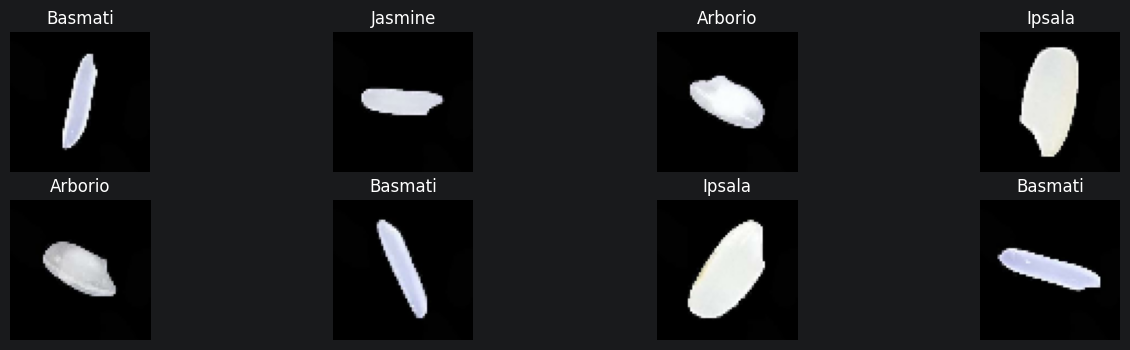

In [2]:
plot_samples(train_images, label_names)

# Building the model

Since we want an overfitting model (ca. 400'000 parameters) we use 5 layers. between each we scale down the image using a max pooling.
4 of the 5 layers are Convolutional layers, working in a 3x3 area. Starting from 256 Kernels (halving every layer).
In the last layer we flatten the image from two dimensions into one and feed it onto a Dense layer. Which in outputs 5 nodes, each for one rice class, so we can know, which has the highest probability.

As we can see in the summary below, the second layer has the most parameters, since the previous layer had 256 kernels, where as the first has only 3.

In [3]:
model = models.Sequential([
    layers.Input(shape=image_size + (3,)),
    layers.Conv2D(256, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(128, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(64, (3,3), activation="relu"),
    layers.MaxPooling2D((2,2)),
    layers.Conv2D(32, (3,3), activation="relu"),
    layers.Flatten(),
    layers.Dense(len(label_names), activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 62, 62, 256)    │         7,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 31, 31, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 29, 29, 128)    │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 32)       │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         2,565 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 397,029 (1.51 MB)

 Trainable params: 397,029 (1.51 MB)

 Non-trainable params: 0 (0.00 B)

# Compiling and Training the model

Here we compile the model and train it using the train and validation data.
We chose to use 30 Epochs here, so we can see clearly that the model is overfitting.

The training will take a while, why we recommend to use linux, since it is multiple times faster than windows.

In [4]:
model.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

history = model.fit(train_images, epochs=30, validation_data=validation_images)

Epoch 1/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.8996 - loss: 0.8496 - val_accuracy: 0.9650 - val_loss: 0.1442
Epoch 2/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.9728 - loss: 0.0873 - val_accuracy: 0.9796 - val_loss: 0.0697
Epoch 3/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 21s 73ms/step - accuracy: 0.9774 - loss: 0.0756 - val_accuracy: 0.9708 - val_loss: 0.1084
Epoch 4/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.9800 - loss: 0.0634 - val_accuracy: 0.9836 - val_loss: 0.0455
Epoch 5/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.9831 - loss: 0.0536 - val_accuracy: 0.9836 - val_loss: 0.0461
Epoch 6/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 21s 72ms/step - accuracy: 0.9834 - loss: 0.0497 - val_accuracy: 0.9912 - val_loss: 0.0249
Epoch 7/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.9844 - loss: 0.0438 - val_accuracy: 0.9889 - val_loss: 0.0318
Epoch 8/30
283/283 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.9849 - loss: 0.0466 - 

# Evaluating the model

## Preparing
To evaluate the model we first run some images through the model and look at the predictions the model has made.

After that we use those prediction together with the true values to plot some graphs and evaluate how good the models behaves and if it really overfits.

## Plots
### Accuracy/Loss
The first two plots show us the accuracy and the loss, where the loss is in a log y-scale, to better see the difference between the Epochs.

The training accuracy rises quick and then flattens out, where as the validation fluctuates quite ab it even from the beginning.
Despite this both seem to rise slowly to 99%.

### Confusion Matrix
We have 4 diffrent Confustion matrix plotted, which show us how often and waht the images has been classified as.
Firstly we can see that the last class (Karacadag) is not beeing clasified as good aas the others, due to the fact that it only has 150 images. Despite thsi it is quite good.
Secondly we can see that the classes 2 and 4 (Basmati and Jasmine) are mistaken for each other a few times, In the iamges plotted earlier we can see that both are slim and long, which explains it.

### Scores
The last three plots show us the F-score, Precision and Recall. All of them are very high except for the last class.

In [5]:
true, pred = calculate_predictions(model, test_images)

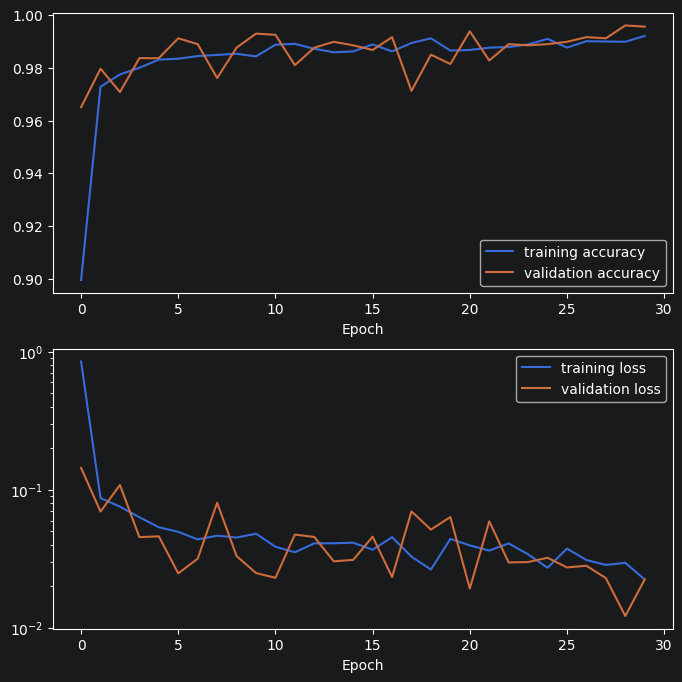

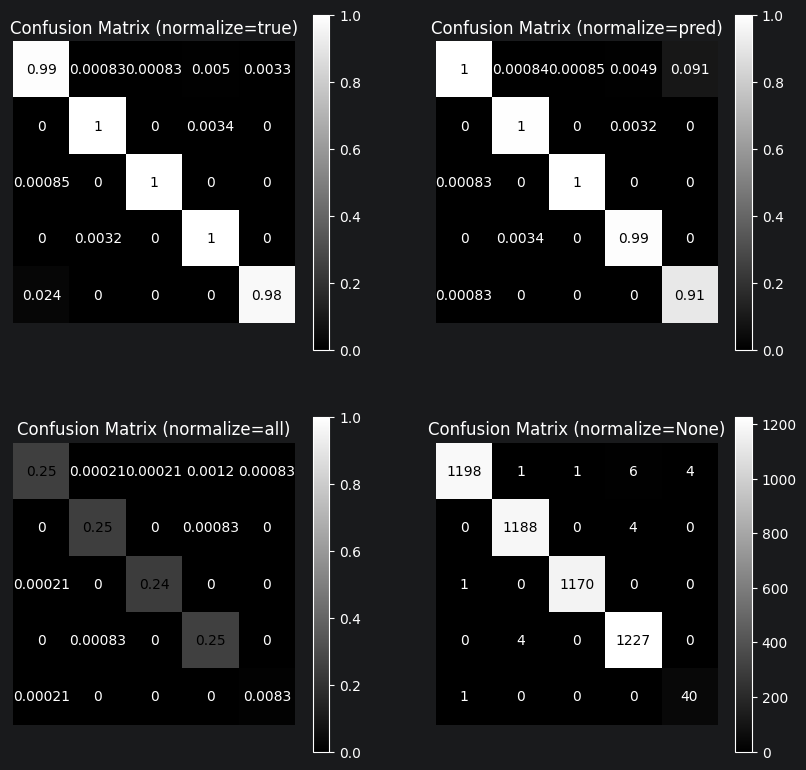

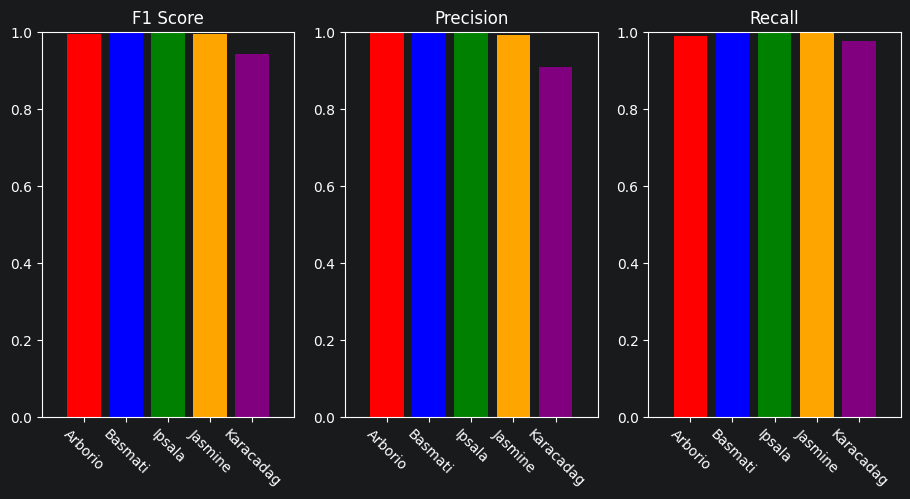

In [6]:
plot_accuracy_and_loss(history.history["accuracy"], history.history["val_accuracy"], history.history["loss"], history.history["val_loss"])

plot_confusion_matrix(true, pred, label_names)
plot_scores(true, pred, label_names)